# Credit Risk Dataset - Initial Investigation

This notebook profiles the dataset (`credit_risk_dataset.csv`), flags quality issues and cleans them before any modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Investigate data

In [2]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())
print("\nMissing value %:")
print((df.isnull().mean() * 100).round(2))

Shape: (32581, 12)

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing value %:
person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64


In [3]:

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes:")
print(df.dtypes)


Duplicate rows: 165

Dtypes:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


### Duplicates and missing data

There are **165 exact duplicate rows**. These are dropped below, since keeping them would let the same applicant profile influence a model multiple times.

Two columns have missing values:
- `person_emp_length` - 2.7% missing
- `loan_int_rate` - 9.6% missing

Both are numeric and could be missing for genuine reasons (e.g. rate not yet assigned, employment length not recorded). Median imputation is reasonable for `person_emp_length`, but `loan_int_rate` is worth checking against `loan_grade` first, since interest rate is typically set by grade - if so, imputing per-grade median is more accurate than a single global median.

In [4]:
df = df.drop_duplicates().reset_index(drop=True)

# Interest rate looks like it should track loan_grade closely - check before imputing globally
print(df.groupby("loan_grade")["loan_int_rate"].agg(["mean", "median", "count"]))

                 mean  median  count
loan_grade                          
A            7.328423   7.490   9713
B           10.995756  10.990   9337
C           13.464579  13.480   5809
D           15.360698  15.310   3309
E           17.008409  16.820    880
F           18.609159  18.535    214
G           20.251525  20.160     59


In [5]:
# Impute loan_int_rate per grade (more accurate than a single global median)
df["loan_int_rate"] = df.groupby("loan_grade")["loan_int_rate"].transform(
    lambda s: s.fillna(s.median())
)

# person_emp_length: no obvious grouping column drives it - use global median
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

df[["loan_int_rate", "person_emp_length"]].isnull().sum()

loan_int_rate        0
person_emp_length    0
dtype: int64

### Target variable: `loan_status`

`loan_status` is 1 if the loan defaulted, 0 if repaid.

loan_status
0    25327
1     7089
Name: count, dtype: int64
loan_status
0    0.781
1    0.219
Name: proportion, dtype: float64


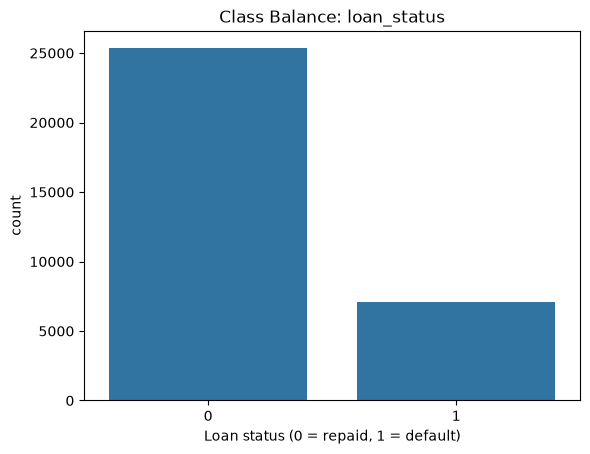

In [6]:
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="loan_status")
plt.title("Class Balance: loan_status")
plt.xlabel("Loan status (0 = repaid, 1 = default)")
plt.show()

**21.8% of loans in this sample defaulted** - slightly imbalanced; manageable with:
- Stratified train/test/CV splits (essential regardless of imbalance handling)
- Class weighting in the model (`class_weight="balanced"` or equivalent)
- Resampling (SMOTE, undersampling) if a simpler model needs it

### Implausible values

Data contains rows with values that can't be real.

In [7]:
# Impossible ages
print("Rows with person_age > 90:")
print(df[df["person_age"] > 90][["person_age", "person_income", "person_emp_length", "loan_status"]])

# Employment length longer than plausible working life given age
implausible_emp = df[df["person_emp_length"] > (df["person_age"] - 16)]
print(f"\nRows where emp_length exceeds (age - 16): {len(implausible_emp)}")
print(implausible_emp[["person_age", "person_emp_length"]].sort_values("person_emp_length", ascending=False).head(10))

Rows with person_age > 90:
       person_age  person_income  person_emp_length  loan_status
81            144         250000                4.0            0
183           144         200000                4.0            0
575           123          80004                2.0            0
747           123          78000                7.0            0
32132         144        6000000               12.0            0
32251          94          24000                1.0            0

Rows where emp_length exceeds (age - 16): 737
       person_age  person_emp_length
0              22              123.0
210            21              123.0
32350          53               38.0
31708          46               31.0
32099          46               31.0
30670          40               25.0
32043          40               25.0
31666          39               24.0
31437          38               23.0
30247          38               23.0


7 rows have `person_age` of 84–144 - physically impossible, almost certainly data entry errors (e.g. extra digit). 

Plus, 740 rows have `person_emp_length` implausibly high relative to `person_age` (some as extreme as 123 years of employment). Since these are a small fraction of 32K rows, dropping them is safer than trying to guess a correction.

In [8]:
before = len(df)

df = df[df["person_age"] <= 90]
df = df[df["person_emp_length"] <= (df["person_age"] - 16)]

print(f"Dropped {before - len(df)} rows ({(before - len(df)) / before * 100:.1f}%)")
print("Remaining shape:", df.shape)

Dropped 743 rows (2.3%)
Remaining shape: (31673, 12)


### Income outlier

count    3.167300e+04
mean     6.585146e+04
std      5.278863e+04
min      4.000000e+03
25%      3.840000e+04
50%      5.500000e+04
75%      7.905000e+04
max      2.039784e+06
Name: person_income, dtype: float64


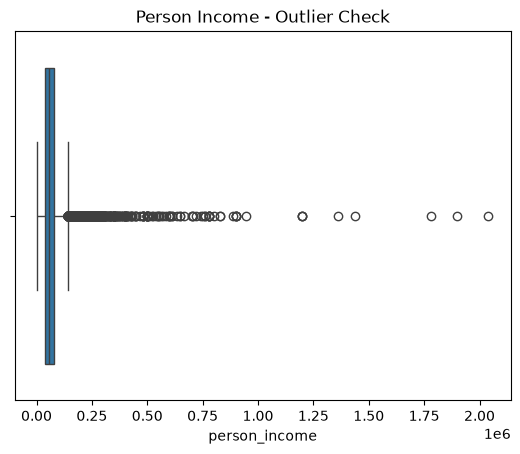

In [9]:
print(df["person_income"].describe())

sns.boxplot(x=df["person_income"])
plt.title("Person Income - Outlier Check")
plt.show()

Income is heavily right-skewed with a maximum of $6,000,000 against a 75th percentile of around $79, 000, an extreme outlier that will distort distance-based models and skew scaling. 
Instead of dropping potential, legitimate high earners, capping at a high percentile is a safer default that preserves the row while limiting its leverage.

In [ ]:
cap = df["person_income"].quantile(0.995)
print(f"Capping at 99.5th percentile: {cap:,.0f}")

n_capped = (df["person_income"] > cap).sum()
df["person_income"] = df["person_income"].clip(upper=cap)
print(f"Rows capped: {n_capped}")

## Data visualisation

### Relationship between loan grade and default rate

loan_status      0      1
loan_grade               
A            0.901  0.099
B            0.837  0.163
C            0.793  0.207
D            0.406  0.594
E            0.349  0.651
F            0.297  0.703
G            0.017  0.983


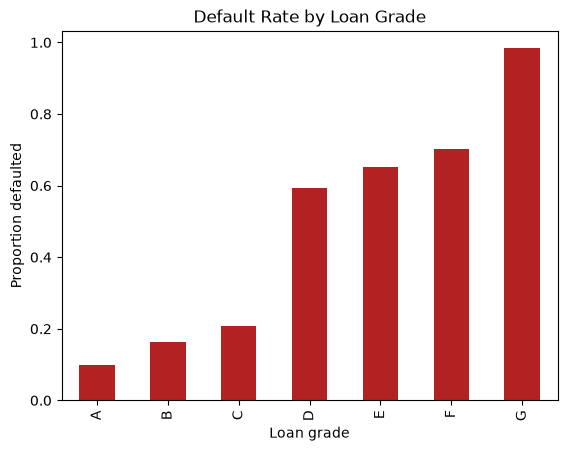

In [10]:
grade_default = pd.crosstab(df["loan_grade"], df["loan_status"], normalize="index")
print(grade_default.round(3))

grade_default[1].sort_index().plot(kind="bar", color="firebrick")
plt.title("Default Rate by Loan Grade")
plt.ylabel("Proportion defaulted")
plt.xlabel("Loan grade")
plt.show()

Default rate climbs sharply and almost monotonically with grade: around 10% at grade A up to 98% at grade G. This is a strong, clean signal showing data is consistent.

**Caveat:** this also makes `loan_grade` a leakage risk. Loan grades are normally assigned by a lender's own risk model at origination, effectively encoding a judgment about default risk *before* it's known. Including it as a predictor risks building a model that just reconstructs the existing grading system rather than learning independently predictive signal. 

This is included and will be treated as a baseline to beat.

Alternatively, this could have been excluded, along with `loan_int_rate` (which likely derives from grade too).

### Correlation between numeric features and the target

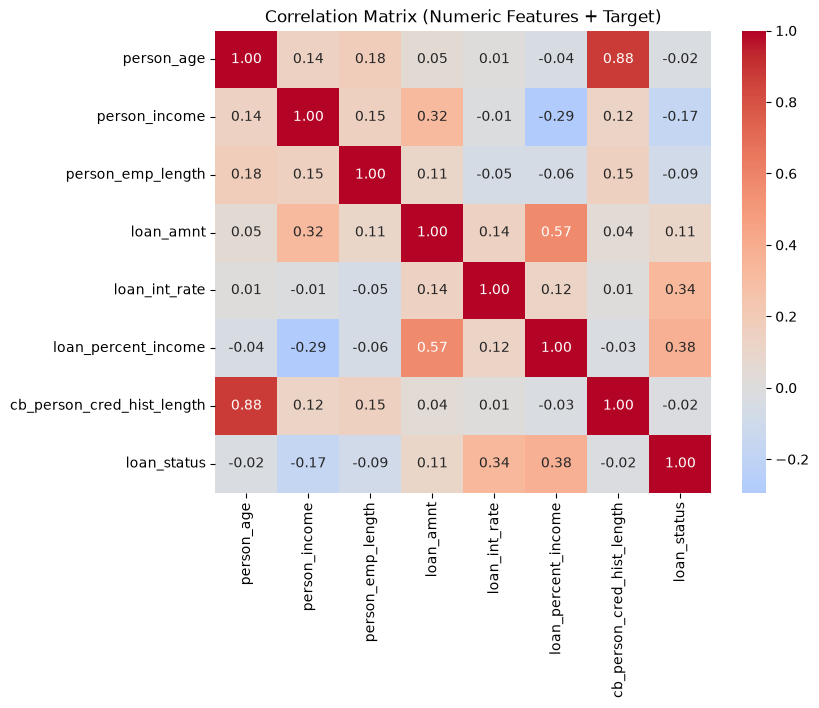

In [11]:
numeric_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
                "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length", "loan_status"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features + Target)")
plt.show()

The two strongest predictors of `loan_status` among the numeric features are:
- **`loan_percent_income`** (r ≈ 0.38) — the loan amount as a fraction of the borrower's income. Makes sense: a loan that's a bigger bite out of income is riskier.
- **`loan_int_rate`** (r ≈ 0.34) — again plausible, though this overlaps with the `loan_grade` leakage concern above since rate is largely grade-derived.

`person_age` and `cb_person_cred_hist_length` are almost perfectly correlated with each other (r ≈ 0.86) — unsurprising, since credit history length can't exceed age by much. Only one of these is likely needed in a model; including both risks multicollinearity for little gain.

`person_income` has a modest *negative* correlation with default (r ≈ -0.14) - higher earners default less, as expected - while `loan_amnt` alone is only weakly related (r ≈ 0.11), which suggests it's the loan size *relative to income* that matters, not the raw amount.

### Home ownership and loan intent vs. default rate

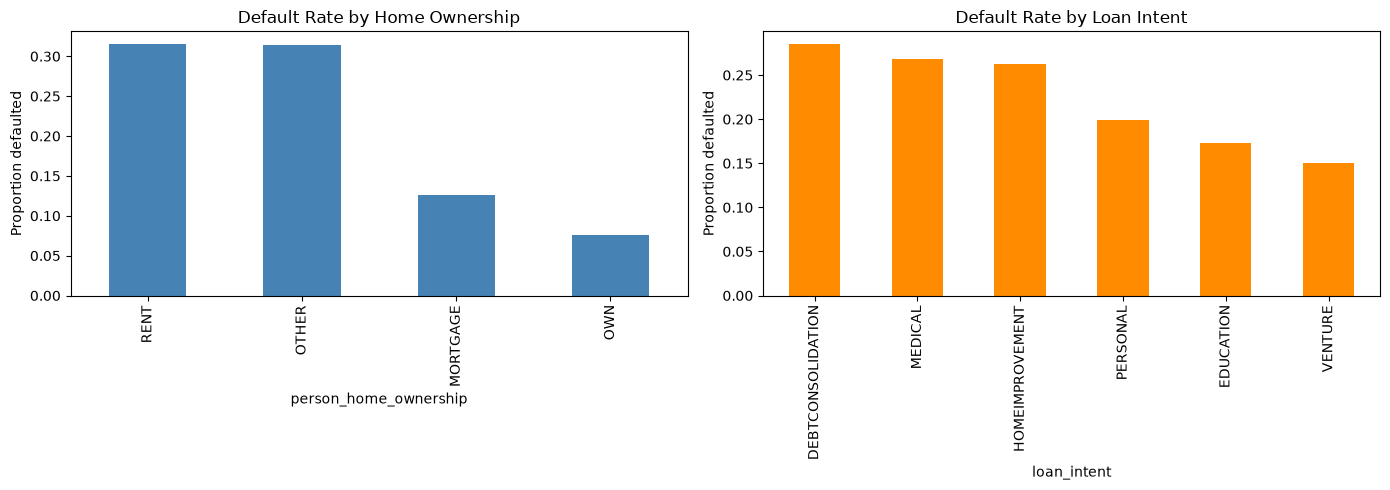

person_home_ownership
RENT        0.316
OTHER       0.314
MORTGAGE    0.127
OWN         0.075
Name: 1, dtype: float64

loan_intent
DEBTCONSOLIDATION    0.285
MEDICAL              0.268
HOMEIMPROVEMENT      0.263
PERSONAL             0.199
EDUCATION            0.173
VENTURE              0.150
Name: 1, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ho = pd.crosstab(df["person_home_ownership"], df["loan_status"], normalize="index")[1].sort_values(ascending=False)
ho.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Default Rate by Home Ownership")
axes[0].set_ylabel("Proportion defaulted")

li = pd.crosstab(df["loan_intent"], df["loan_status"], normalize="index")[1].sort_values(ascending=False)
li.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Default Rate by Loan Intent")
axes[1].set_ylabel("Proportion defaulted")

plt.tight_layout()
plt.show()

print(ho.round(3))
print()
print(li.round(3))

Renters default at a noticeably higher rate than mortgage-holders or outright owners. Plausible, since home ownership is a rough indication for financial stability. `loan_intent` shows a smaller spread: `DEBTCONSOLIDATION` and `MEDICAL` loans default somewhat more than `VENTURE` or `EDUCATION`, though the gap here is less pronounced than for home ownership or loan grade.

## Summary of cleaning applied

- Dropped 165 exact duplicate rows
- Imputed `loan_int_rate` per loan grade, `person_emp_length` with the global median
- Dropped rows with impossible `person_age` (>90) or `person_emp_length` inconsistent with age
- Capped `person_income` at the 99.5th percentile

### Decisions:

1. **`loan_grade` / `loan_int_rate` leakage** included to treat as a baseline.
2. **`person_age` vs. `cb_person_cred_hist_length`** — near-duplicate information so consider dropping one; 
cb_person_cred_hist_length had the weaker relationship with the target(loan_status) so is the safer one to drop
3. **Class imbalance (78/22)** — plan for stratified splits and class weighting at minimum.

In [22]:
correlations = corr.loc[["person_age", "cb_person_cred_hist_length"], "loan_status"]
strongest_column = correlations.abs().idxmax()

strongest_correlation = correlations[strongest_column]

print(correlations)
print(
    f"\nHighest correlation with loan_status: {strongest_column} "
    f"(r = {strongest_correlation:.3f})"
)
print(df.head())

# Drop the weaker of the two highly correlated features
weaker_feature = correlations.abs().idxmin()
df = df.drop(columns=[weaker_feature])

person_age                   -0.021449
cb_person_cred_hist_length   -0.015923
Name: loan_status, dtype: float64

Highest correlation with loan_status: person_age (r = -0.021)
   person_income person_home_ownership  person_emp_length loan_intent  \
1           9600                   OWN                5.0   EDUCATION   
2           9600              MORTGAGE                1.0     MEDICAL   
3          65500                  RENT                4.0     MEDICAL   
4          54400                  RENT                8.0     MEDICAL   
5           9900                   OWN                2.0     VENTURE   

  loan_grade  loan_amnt  loan_int_rate  loan_status  loan_percent_income  \
1          B       1000          11.14            0                 0.10   
2          C       5500          12.87            1                 0.57   
3          C      35000          15.23            1                 0.53   
4          C      35000          14.27            1                 0.55   
5     

KeyError: "['cb_person_cred_hist_length'] not found in axis"